## EDA PART 2
### Equipo 5
Diego Ponce de León Betanzos A01664407  
Kate Rodriguez Reyes A01234357  
Ana Sofia sosa de León A01178529  
Paulo Emilio Aranalde A00839602  
María Fernanda García Bautista A00837361  

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv("../EDAgroup5/data/g5_dataSample_v2.csv")

print(f"shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"unique users (userId): {df['userId'].nunique():,}")
print(f"duplicate (userId, mes) rows: {df.duplicated(subset=['userId', 'mes']).sum()}")
df.head()

shape: 921,438 rows x 29 columns
unique users (userId): 50,000
duplicate (userId, mes) rows: 0


,userId,mes,oxxo_tx_ratio_m,oxxo_ratio_avg_prev3m,oxxo_ratio_delta_m,ecommerce_tx_ratio_m,virtual_card_ratio_m,intl_tx_ratio_m,tx_count_m,tx_amount_sum_m,tx_amount_avg_m,tx_count_delta_m,merchant_entropy_m,unique_mcc_m,cash_funding_ratio_m,spei_amount_m,spend_to_fund_ratio_m,decline_ratio_m,recovery_avg_min_m,next_month_observed,has_next_month,target_oxxo_migration,oxxo_ratio_change_next_m,target_ticket_growth,ticket_change_next_m,target_flip_out_30d,target_flip_in_liquidity_30d,target_flip_in_commercial_30d,target_reactivation_30d
0,SG5_ffffd8bae2c0,2026-07-01,0.219512,0.280692,-0.206818,0.707317,0.0,0.0,41,1492.89,36.411951,-4.0,1.499191,4,NaN,0.0,NaN,0.211538,1508.909091,1,1,0.0,0.184091,1.0,0.519005,NaN,1.0,1.0,NaN
1,SG5_0fe545c31e56,2025-06-01,0.000000,0.000000,NaN,0.000000,0.0,0.0,0,0.00,0.000000,-1.0,0.000000,0,NaN,0.0,NaN,1.000000,58242.066667,1,1,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN
2,SG5_10f352c84951,2025-06-01,0.000000,NaN,NaN,0.000000,0.0,0.0,0,0.00,0.000000,0.0,0.000000,0,1.0,0.0,0.0,0.000000,NaN,1,1,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0
3,SG5_146c91341cf4,2025-06-01,0.000000,0.000000,NaN,0.000000,0.0,0.0,0,0.00,0.000000,0.0,0.000000,0,NaN,0.0,NaN,1.000000,191396.333333,1,0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0
4,SG5_1757806bfc41,2025-06-01,0.000000,0.000000,NaN,0.000000,0.0,0.0,0,0.00,0.000000,0.0,0.000000,0,1.0,0.0,0.0,0.000000,NaN,1,1,NaN,NaN,NaN,NaN,0.0,NaN,NaN,1.0


## Dataset Overview & Business Context

`g5_dataSample_v2.csv` is **Grupo 5's column set** from the shared panel (`userId`, `mes`),
plus the cross-team `target_*` labels, restricted to a **"flip" sample** built for the
Flip-Out / Flip-In modeling task described in the data dictionary.

This is the **v2 replacement database**: same `(userId, mes)` grain and the same G5 +
`TODOS` columns as the file used in `initialEDA.ipynb`, but a different draw —
**921,438 rows / 50,000 users / 19 months (2025-01 to 2026-07)**, no duplicate
`(userId, mes)` keys, and every user's history is a **contiguous run** (no calendar
gaps — the smallest observed gap between consecutive rows for a user is a normal
28/30/31-day month-to-month step). Unlike the prior extract, `next_month_observed`
is **constant at 1** here (the sample excludes each user's final observed month), so
it can't be used as a filter the way the Pilar 1 write-up on the old file assumed —
`has_next_month` is the only usable next-month-activity flag in this file.

In [2]:
df.info()
display(df.describe().T)

<class 'pandas.DataFrame'>
RangeIndex: 921438 entries, 0 to 921437
Data columns (total 29 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   userId                         921438 non-null  str    
 1   mes                            921438 non-null  str    
 2   oxxo_tx_ratio_m                921438 non-null  float64
 3   oxxo_ratio_avg_prev3m          743099 non-null  float64
 4   oxxo_ratio_delta_m             679286 non-null  float64
 5   ecommerce_tx_ratio_m           921438 non-null  float64
 6   virtual_card_ratio_m           921438 non-null  float64
 7   intl_tx_ratio_m                921438 non-null  float64
 8   tx_count_m                     921438 non-null  int64  
 9   tx_amount_sum_m                921438 non-null  float64
 10  tx_amount_avg_m                921438 non-null  float64
 11  tx_count_delta_m               871438 non-null  float64
 12  merchant_entropy_m             921438 non

,count,mean,std,min,25%,50%,75%,max
oxxo_tx_ratio_m,921438.0,0.089272,0.201977,0.0,0.000000,0.000000,0.066667,1.000000
oxxo_ratio_avg_prev3m,743099.0,0.107304,0.196675,0.0,0.000000,0.000000,0.128205,1.000000
oxxo_ratio_delta_m,679286.0,-0.002372,0.182757,-1.0,0.000000,0.000000,0.000000,1.000000
ecommerce_tx_ratio_m,921438.0,0.452959,0.436154,0.0,0.000000,0.333333,1.000000,1.000000
virtual_card_ratio_m,921438.0,0.120620,0.298111,0.0,0.000000,0.000000,0.000000,1.000000
intl_tx_ratio_m,921438.0,0.114150,0.255180,0.0,0.000000,0.000000,0.055556,1.000000
tx_count_m,921438.0,9.869502,17.200182,0.0,1.000000,4.000000,12.000000,1137.000000
tx_amount_sum_m,921438.0,2382.181225,5208.545320,0.0,141.230000,797.895000,2589.705000,210873.040000
tx_amount_avg_m,921438.0,248.939559,483.826759,0.0,52.456167,134.600000,284.965632,66547.700000
tx_count_delta_m,871438.0,0.178054,10.809789,-682.0,-3.000000,0.000000,3.000000,666.000000


# Pilar 1 — Missing Value Diagnostic & Resolution

- **Group A — lag/rolling nulls**: `tx_count_delta_m` is null **only** on each user's
  first panel month (pure lag null, recoverable: fill `0.0`, no prior month to compare
  to). `oxxo_ratio_delta_m` and `oxxo_ratio_avg_prev3m` are null on the first month(s)
  **plus** an activity-gated layer — null whenever this month, the prior month, or (for
  the 3-month average) *all three* prior months had zero transactions, since a
  ratio-of-nothing comparison is undefined rather than zero. Verified below: both
  patterns match their null masks exactly.
- **Group B — no-funding-event nulls**: `cash_funding_ratio_m` / `spend_to_fund_ratio_m`
  are null together, every time — 0/0 undefined when `funding_amount_total_m = 0`.
  Notably this is **not** the same as "no purchases that month": most of these null
  rows (74%) have `tx_count_m > 0` — users spending down a balance with no new funding
  event that month.
- **Group C — no-friction nulls**: `recovery_avg_min_m` is null whenever there was
  nothing to recover from (`decline_ratio_m == 0`), plus a small residual (~2%) where a
  decline happened but no approved purchase ever followed it in the panel window.
- **Group D — leakage-via-nullity**: `oxxo_ratio_change_next_m` / `ticket_change_next_m`
  are null on **exactly** the same rows as `target_oxxo_migration` / `target_ticket_growth`
  (by construction — the label only exists where the continuous delta does), and the
  binary labels reproduce their documented thresholds (`<= -0.05`, `>= 0.10`) with a
  100% match on every non-null row. Left as NaN — these rows simply have no defined
  next-month comparison (this month or next month had zero activity), not missing data.
- **Group E — eligibility-gated target nulls**: the three `target_flip_*` columns and
  `target_reactivation_30d` are null for users who weren't eligible that month, not
  missing-at-random labels to fill in.

In [3]:
null_summary = pd.DataFrame({
    "n_null": df.isna().sum(),
    "pct_null": (df.isna().mean() * 100).round(2),
    "dtype": df.dtypes.astype(str),
})
null_summary = null_summary[null_summary["n_null"] > 0].sort_values("pct_null", ascending=False)
null_summary

,n_null,pct_null,dtype
target_reactivation_30d,860840,93.42,float64
target_flip_out_30d,609119,66.11,float64
recovery_avg_min_m,404790,43.93,float64
cash_funding_ratio_m,338005,36.68,float64
spend_to_fund_ratio_m,338005,36.68,float64
oxxo_ratio_delta_m,242152,26.28,float64
target_oxxo_migration,205437,22.30,float64
oxxo_ratio_change_next_m,205437,22.30,float64
target_ticket_growth,205482,22.30,float64
ticket_change_next_m,205482,22.30,float64


## Group A — lag/rolling nulls: recompute from the user's own history first

Sorting by `(userId, mes)`, every user's rows are a contiguous monthly run (no gaps),
and the raw inputs (`tx_count_m`, `oxxo_tx_ratio_m`) carry **zero nulls**. So the null
mask on each lag/rolling column can be explained exactly from that same history instead
of guessed at with a dataset-wide statistic — checked below before filling anything.

In [4]:
df_c = df.sort_values(["userId", "mes"]).reset_index(drop=True).copy()
df_c["month_num"] = df_c.groupby("userId").cumcount()

# tx_count_delta_m: null only on each user's first month (pure lag null)
first_month = df_c["month_num"] == 0
print("tx_count_delta_m null == first_month exactly:",
      (df_c["tx_count_delta_m"].isna() == first_month).all())

# oxxo_ratio_delta_m: null on first month OR when this/prev month had zero activity
g = df_c.groupby("userId")
prev_tx = [g["tx_count_m"].shift(k) for k in (1, 2, 3)]
no_prev_activity = prev_tx[0].isna() | (prev_tx[0] == 0) | (df_c["tx_count_m"] == 0)
print("oxxo_ratio_delta_m null == (first month OR this/prev inactive):",
      (df_c["oxxo_ratio_delta_m"].isna() == no_prev_activity).all())

# oxxo_ratio_avg_prev3m: null in first 3 months OR when all 3 prior months were inactive
all3_inactive = pd.concat(prev_tx, axis=1).fillna(0).eq(0).all(axis=1) & df_c["month_num"].ge(3)
first3 = df_c["month_num"] < 3
print("oxxo_ratio_avg_prev3m null == (first 3 months OR all-3-prev inactive):",
      (df_c["oxxo_ratio_avg_prev3m"].isna() == (first3 | all3_inactive)).all())

# Both patterns confirmed exactly -> these are by-design "undefined comparison" nulls,
# not recoverable missing data. Flag + fill 0.0 (neutral: "no observed change").
for col in ["tx_count_delta_m", "oxxo_ratio_delta_m", "oxxo_ratio_avg_prev3m"]:
    df_c[f"{col}_was_missing"] = df_c[col].isna()
    df_c[col] = df_c[col].fillna(0.0)

df_c[["tx_count_delta_m_was_missing", "oxxo_ratio_delta_m_was_missing",
      "oxxo_ratio_avg_prev3m_was_missing"]].sum()

tx_count_delta_m null == first_month exactly: True
oxxo_ratio_delta_m null == (first month OR this/prev inactive): True
oxxo_ratio_avg_prev3m null == (first 3 months OR all-3-prev inactive): True


tx_count_delta_m_was_missing          50000
oxxo_ratio_delta_m_was_missing       242152
oxxo_ratio_avg_prev3m_was_missing    178339
dtype: int64

## Group B — no-funding-event nulls

`cash_funding_ratio_m` and `spend_to_fund_ratio_m` are undefined by the same 0/0
condition (`funding_amount_total_m = 0`), so they're null on the exact same rows —
confirmed below. Flag those rows with `is_zero_funding_m` and fill both ratios with
`0.0` — neutral, since there's no funding-mix or spend-velocity signal to report when
nothing was funded. Note this is **not** interchangeable with "no purchases": most
zero-funding rows still have `tx_count_m > 0` (spend drawn from an existing balance).

In [5]:
cash_null = df_c["cash_funding_ratio_m"].isna()
spend_null = df_c["spend_to_fund_ratio_m"].isna()
print("cash_funding_ratio_m null == spend_to_fund_ratio_m null (same rows):", (cash_null == spend_null).all())

n_with_tx = int((cash_null & (df_c["tx_count_m"] > 0)).sum())
print(f"zero-funding rows with tx_count_m > 0: {n_with_tx:,} / {int(cash_null.sum()):,} "
      f"({n_with_tx / cash_null.sum() * 100:.1f}%) -> spend from existing balance, not inactivity")

df_c["is_zero_funding_m"] = cash_null
df_c["cash_funding_ratio_m"] = df_c["cash_funding_ratio_m"].fillna(0.0)
df_c["spend_to_fund_ratio_m"] = df_c["spend_to_fund_ratio_m"].fillna(0.0)

cash_funding_ratio_m null == spend_to_fund_ratio_m null (same rows): True
zero-funding rows with tx_count_m > 0: 251,506 / 338,005 (74.4%) -> spend from existing balance, not inactivity


## Group C — no-friction nulls

`recovery_avg_min_m` (avg minutes between a decline and the next approved purchase)
is null whenever there was no decline to recover from (`decline_ratio_m == 0`), plus a
small residual where a decline happened but no approved purchase ever followed it
within the panel window. Derive `had_decline_m` from `decline_ratio_m > 0`, fill the
no-decline rows with `0.0`, and leave the no-subsequent-purchase residual as NaN since
"no recovery happened yet" is genuinely unknown, not zero.

In [6]:
df_c["had_decline_m"] = df_c["decline_ratio_m"] > 0
rec_null = df_c["recovery_avg_min_m"].isna()

no_decline = rec_null & ~df_c["had_decline_m"]
decline_no_recovery = rec_null & df_c["had_decline_m"]
print(f"recovery_avg_min_m null & no decline: {int(no_decline.sum()):,} -> fill 0.0")
print(f"recovery_avg_min_m null & had decline (no purchase ever followed): {int(decline_no_recovery.sum()):,} -> left as NaN")

df_c["recovery_avg_min_m_was_missing"] = no_decline
df_c.loc[no_decline, "recovery_avg_min_m"] = 0.0

recovery_avg_min_m null & no decline: 396,226 -> fill 0.0
recovery_avg_min_m null & had decline (no purchase ever followed): 8,564 -> left as NaN


## Group D — leakage-via-nullity (do **not** impute)

Checking the null pattern of `oxxo_ratio_change_next_m` against `target_oxxo_migration`
(and `ticket_change_next_m` against `target_ticket_growth`): in this file the two null
masks are **identical**, by construction — the binary label only exists where its
continuous driver does, since both require activity in the current *and* next month.
And on every row where the continuous value is populated, the binary label reproduces
it exactly via the documented threshold. These are left as NaN: the null rows have no
defined next-month comparison at all (not an unobserved outcome to fill in).

In [7]:
for cont_col, tgt_col, lo in [("oxxo_ratio_change_next_m", "target_oxxo_migration", -0.05),
                               ("ticket_change_next_m", "target_ticket_growth", 0.10)]:
    same_mask = (df_c[cont_col].isna() == df_c[tgt_col].isna()).all()
    pop = df_c[cont_col].notna()
    op = (df_c.loc[pop, cont_col] <= lo) if lo < 0 else (df_c.loc[pop, cont_col] >= lo)
    reproduces = (op.astype(int) == df_c.loc[pop, tgt_col].astype(int)).all()
    print(f"{tgt_col:25s} null mask matches {cont_col}: {same_mask}   "
          f"reproduces via threshold {lo:+.2f}: {reproduces}")

target_oxxo_migration     null mask matches oxxo_ratio_change_next_m: True   reproduces via threshold -0.05: True
target_ticket_growth      null mask matches ticket_change_next_m: True   reproduces via threshold +0.10: True


## Group E — eligibility-gated target nulls (do **not** impute)

These nulls encode "not eligible for this label that month," not a missing
observation — filling them with 0 or a median would silently turn ineligible users
into (fake) negatives.

In [ ]:
df_c["eligible_flip_out_m"] = df_c["target_flip_out_30d"].notna()
df_c["eligible_flip_in_m"] = df_c["target_flip_in_liquidity_30d"].notna()  # shared ESR>=0.30 gate
df_c["eligible_reactivation_m"] = df_c["target_reactivation_30d"].notna()

for col in ["target_flip_out_30d", "target_flip_in_liquidity_30d",
            "target_flip_in_commercial_30d", "target_reactivation_30d"]:
    n_elig = df_c[col].notna().sum()
    rate = df_c[col].mean(skipna=True) * 100
    print(f"{col:30s} eligible={n_elig:,} ({n_elig / len(df_c) * 100:.1f}%)  positive_rate={rate:.2f}%")

print("\n-> left as NaN for ineligible rows;")

target_flip_out_30d            eligible=312,319 (33.9%)  positive_rate=34.73%
target_flip_in_liquidity_30d   eligible=755,848 (82.0%)  positive_rate=57.08%
target_flip_in_commercial_30d  eligible=755,848 (82.0%)  positive_rate=30.52%
target_reactivation_30d        eligible=60,598 (6.6%)  positive_rate=41.48%

-> left as NaN for ineligible rows; filter on eligible_flip_out_m / eligible_flip_in_m / eligible_reactivation_m before training.


## Pilar 1 — final check

After Groups A-C, every *imputable* null should be resolved. The only remaining NaNs
should be exactly the Group C residual (decline with no subsequent purchase), Group D
(leakage-via-nullity) and Group E (eligibility-gated target) columns, left null by
design.

In [9]:
remaining = df_c.drop(columns=["month_num"]).isna().sum()
remaining = remaining[remaining > 0].sort_values(ascending=False)
print(remaining)

target_reactivation_30d          860840
target_flip_out_30d              609119
target_ticket_growth             205482
ticket_change_next_m             205482
target_oxxo_migration            205437
oxxo_ratio_change_next_m         205437
target_flip_in_liquidity_30d     165590
target_flip_in_commercial_30d    165590
recovery_avg_min_m                 8564
dtype: int64


# Pilar 2 — Consistency Alignment

Bounds and formula checks against the actual columns in this file:

- Every `*_ratio_m` column (except `spend_to_fund_ratio_m`, which isn't bounded to
  [0,1] by definition — it can exceed 1 when spend draws down a prior balance) must
  sit in [0, 1].
- This extract does **not** include `fisico_non_oxxo_tx_ratio_m` (G4-owned), so
  `oxxo_tx_ratio_m + ecommerce_tx_ratio_m` will legitimately be **<= 1** — the
  residual is the physical-non-OXXO channel, simply not exported to this file.
- `tx_amount_avg_m` must equal `tx_amount_sum_m / tx_count_m` wherever `tx_count_m > 0`.
- The binary targets should exactly reproduce their documented threshold formulas on
  the rows where the continuous column is populated (already confirmed in Group D).

In [10]:
ratio_cols = [c for c in df_c.columns if c.endswith("_ratio_m") and c != "spend_to_fund_ratio_m"]
for c in ratio_cols:
    print(f"{c:25s} min={df_c[c].min():.4f}  max={df_c[c].max():.4f}  "
          f"out_of_[0,1]={(((df_c[c] < 0) | (df_c[c] > 1)).sum())}")

combo = df_c["oxxo_tx_ratio_m"] + df_c["ecommerce_tx_ratio_m"]
print(f"\noxxo_tx_ratio_m + ecommerce_tx_ratio_m: max={combo.max():.4f}  "
      f"violations (>1): {(combo > 1.0001).sum()}")

print(f"\nspend_to_fund_ratio_m: min={df_c['spend_to_fund_ratio_m'].min():.2f}  "
      f"max={df_c['spend_to_fund_ratio_m'].max():.2f}  (unbounded by design)")

mask = df_c["tx_count_m"] > 0
calc_avg = df_c.loc[mask, "tx_amount_sum_m"] / df_c.loc[mask, "tx_count_m"]
max_diff = (calc_avg - df_c.loc[mask, "tx_amount_avg_m"]).abs().max()
print(f"\ntx_amount_avg_m vs sum/count formula: max abs diff = {max_diff:.2e}")

oxxo_tx_ratio_m           min=0.0000  max=1.0000  out_of_[0,1]=0
ecommerce_tx_ratio_m      min=0.0000  max=1.0000  out_of_[0,1]=0
virtual_card_ratio_m      min=0.0000  max=1.0000  out_of_[0,1]=0
intl_tx_ratio_m           min=0.0000  max=1.0000  out_of_[0,1]=0
cash_funding_ratio_m      min=0.0000  max=1.0000  out_of_[0,1]=0
decline_ratio_m           min=0.0000  max=1.0000  out_of_[0,1]=0

oxxo_tx_ratio_m + ecommerce_tx_ratio_m: max=1.0000  violations (>1): 0

spend_to_fund_ratio_m: min=0.00  max=863854.00  (unbounded by design)

tx_amount_avg_m vs sum/count formula: max abs diff = 1.82e-12


# Pilar 3 — Correlation & Pre-Clustering Feature Selection

Spearman correlation on the cleaned numeric features, **excluding**: keys (`userId`,
`mes`, `month_num`), structural/constant flags (`next_month_observed`,
`has_next_month`), engineered QA flags (`*_was_missing`, `is_zero_funding_m`,
`had_decline_m`, `eligible_*`), and anything forward-looking (`target_*`, `*_next_m`).

17 candidate features for correlation / clustering:
['oxxo_tx_ratio_m', 'oxxo_ratio_avg_prev3m', 'oxxo_ratio_delta_m', 'ecommerce_tx_ratio_m', 'virtual_card_ratio_m', 'intl_tx_ratio_m', 'tx_count_m', 'tx_amount_sum_m', 'tx_amount_avg_m', 'tx_count_delta_m', 'merchant_entropy_m', 'unique_mcc_m', 'cash_funding_ratio_m', 'spei_amount_m', 'spend_to_fund_ratio_m', 'decline_ratio_m', 'recovery_avg_min_m']



2 redundant pairs (|Spearman rho| >= 0.90):
  +0.940   merchant_entropy_m  <->  unique_mcc_m
  +0.927   decline_ratio_m  <->  recovery_avg_min_m


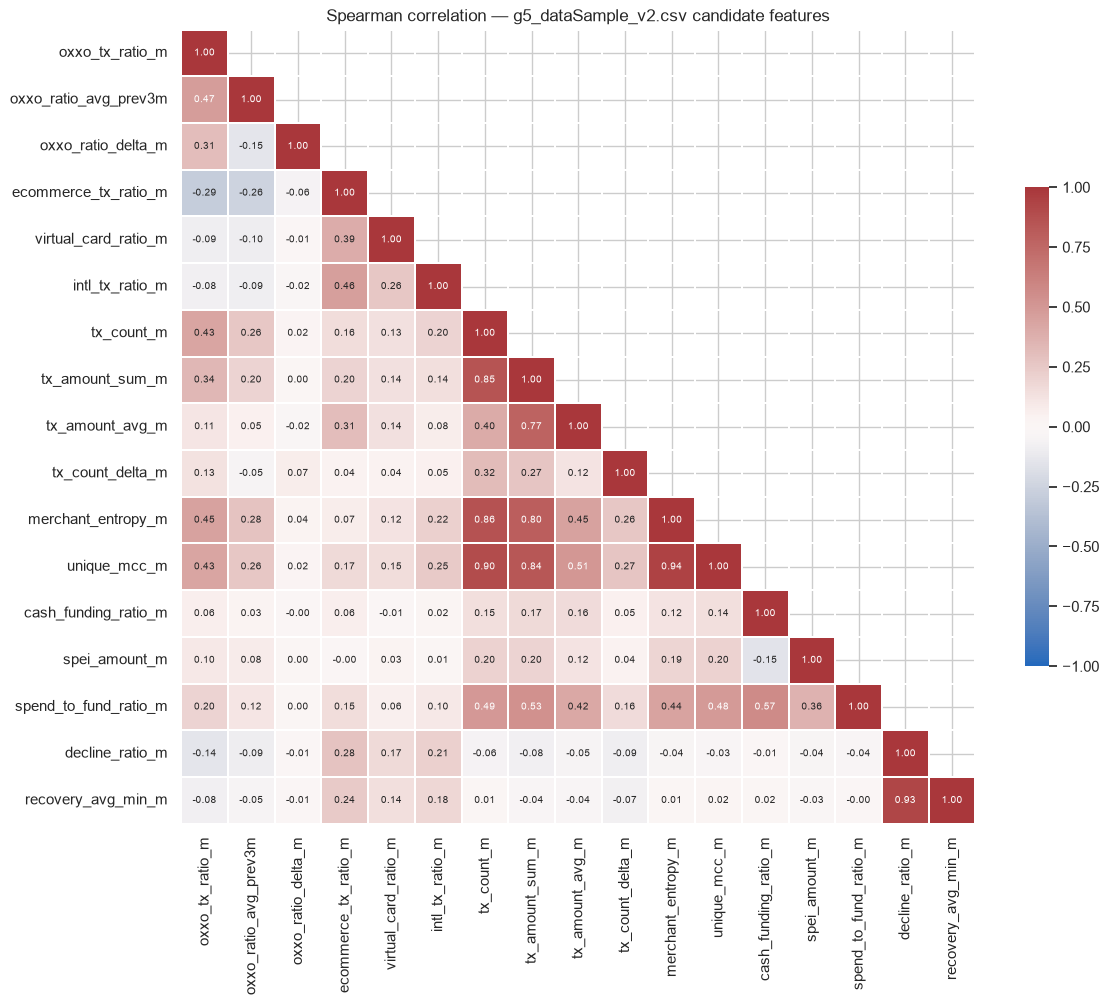

In [11]:
exclude_patterns = ("_was_missing", "target_", "_next_m")
exclude_exact = {
    "userId", "mes", "month_num", "next_month_observed", "has_next_month",
    "is_zero_funding_m", "had_decline_m",
    "eligible_flip_out_m", "eligible_flip_in_m", "eligible_reactivation_m",
}

feature_cols = [
    c for c in df_c.select_dtypes(include=[np.number]).columns
    if c not in exclude_exact and not any(p in c for p in exclude_patterns)
]

num = df_c[feature_cols]
num = num.loc[:, num.nunique() > 1]
print(f"{num.shape[1]} candidate features for correlation / clustering:")
print(list(num.columns))

corr = num.corr("spearman")
cols = corr.columns
redundant = [
    (cols[i], cols[j], corr.iloc[i, j])
    for i in range(len(cols)) for j in range(i + 1, len(cols))
    if abs(corr.iloc[i, j]) >= 0.90
]
redundant.sort(key=lambda t: -abs(t[2]))

print(f"\n{len(redundant)} redundant pairs (|Spearman rho| >= 0.90):")
for a, b, r in redundant:
    print(f"  {r:+.3f}   {a}  <->  {b}")

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap="vlag", center=0, vmin=-1, vmax=1, square=True,
            annot=True, fmt=".2f", annot_kws={"size": 7},
            xticklabels=True, yticklabels=True, linewidths=.3,
            cbar_kws={"shrink": .6}, ax=ax)
ax.set_title("Spearman correlation — g5_dataSample_v2.csv candidate features")
plt.tight_layout()
plt.show()

## Univariate Distributions

Expect heavy zero-inflation: the panel keeps a row for every user-month even when
there was no activity, so `tx_count_m` and everything derived from it (ratios,
entropy, amounts) piles up at 0.

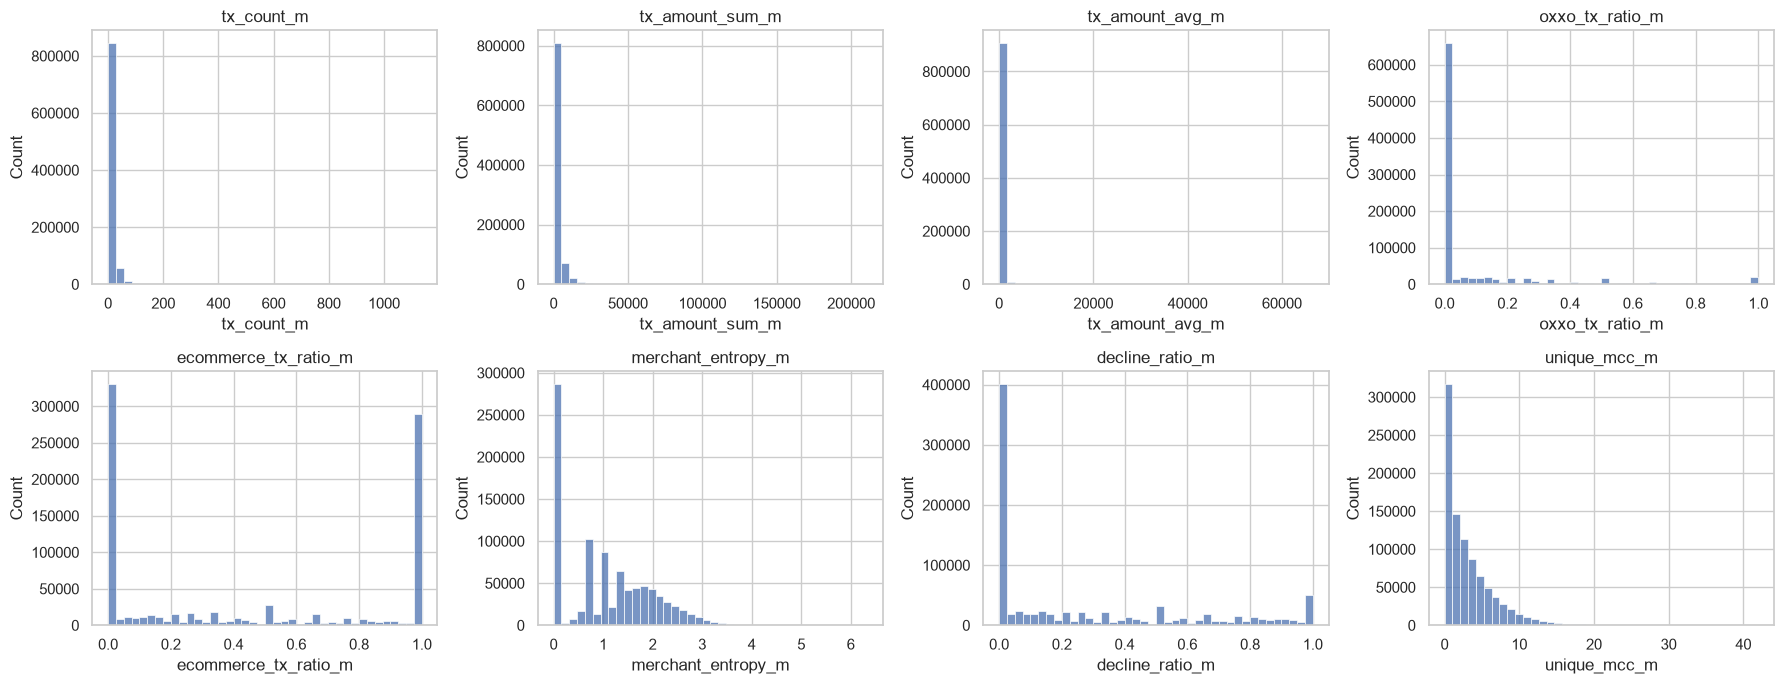

tx_count_m == 0 (no-activity months): 14.9%


In [12]:
hist_cols = ["tx_count_m", "tx_amount_sum_m", "tx_amount_avg_m", "oxxo_tx_ratio_m",
             "ecommerce_tx_ratio_m", "merchant_entropy_m", "decline_ratio_m", "unique_mcc_m"]

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, col in zip(axes.flat, hist_cols):
    sns.histplot(df_c[col], bins=40, ax=ax, color="#4C72B0")
    ax.set_title(col)
plt.tight_layout()
plt.show()

print(f"tx_count_m == 0 (no-activity months): {(df_c['tx_count_m'] == 0).mean() * 100:.1f}%")

## Target Variable Analysis (class balance)

All 5 targets are rare/moderate-event, imbalanced labels. The three `target_flip_*`
columns and `target_reactivation_30d` are additionally **eligibility-gated** (Group E),
so their positive rate is reported within the eligible population only, not the full
panel.

,target,eligible_n,positive_rate_%
0,target_oxxo_migration,921438,17.72
1,target_ticket_growth,921438,41.78
2,target_flip_out_30d,312319,34.73
3,target_flip_in_liquidity_30d,755848,57.08
4,target_flip_in_commercial_30d,755848,30.52
5,target_reactivation_30d,60598,41.48


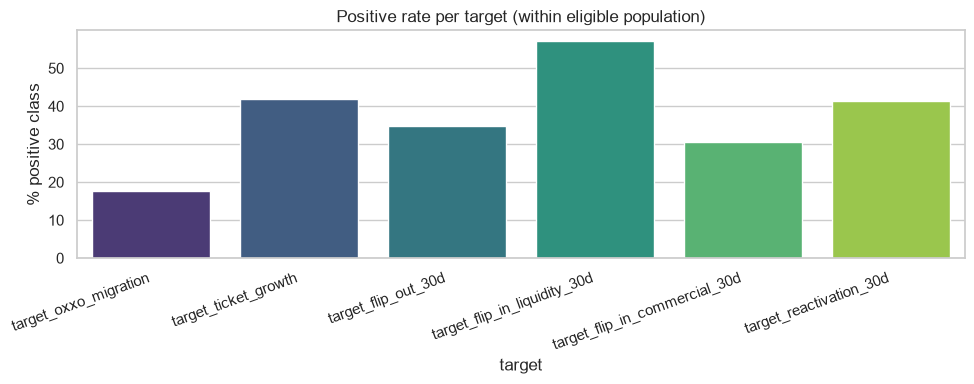

In [13]:
target_specs = [
    ("target_oxxo_migration", None),
    ("target_ticket_growth", None),
    ("target_flip_out_30d", "eligible_flip_out_m"),
    ("target_flip_in_liquidity_30d", "eligible_flip_in_m"),
    ("target_flip_in_commercial_30d", "eligible_flip_in_m"),
    ("target_reactivation_30d", "eligible_reactivation_m"),
]

rows = []
for tgt, elig_flag in target_specs:
    base = df_c[df_c[elig_flag]] if elig_flag else df_c
    rows.append({"target": tgt, "eligible_n": len(base), "positive_rate_%": round(base[tgt].mean() * 100, 2)})
balance = pd.DataFrame(rows)
display(balance)

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=balance, x="target", y="positive_rate_%", hue="target", palette="viridis", legend=False, ax=ax)
ax.set_title("Positive rate per target (within eligible population)")
ax.set_ylabel("% positive class")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## Outlier Screening

IQR-fence check on the money/count/ratio columns most likely to carry extreme values
(`tx_amount_sum_m`, `tx_amount_avg_m`, `spei_amount_m` can reach into the millions of
MXN per the dictionary; `spend_to_fund_ratio_m` is unbounded and observed as high as
~860,000x in this file).

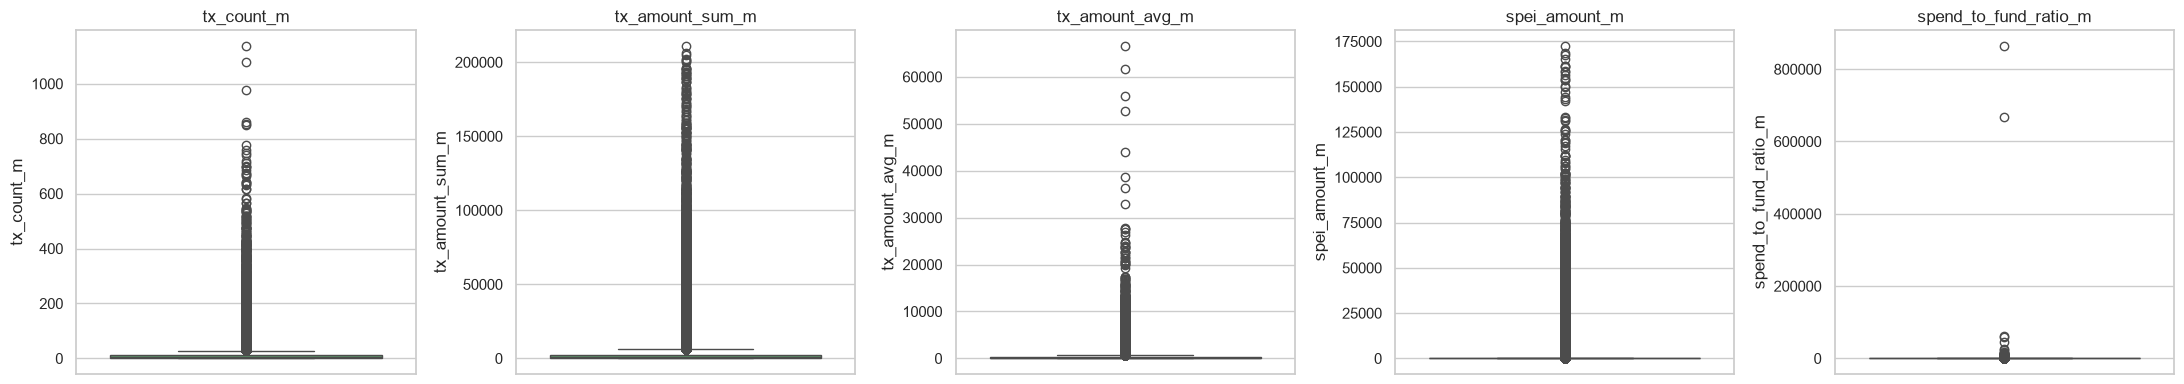

tx_count_m             Q1=1.00  Q3=12.00  upper_fence=28.50  n_above_fence=74,692 (8.1%)
tx_amount_sum_m        Q1=141.23  Q3=2,589.70  upper_fence=6,262.42  n_above_fence=88,335 (9.6%)
tx_amount_avg_m        Q1=52.46  Q3=284.97  upper_fence=633.73  n_above_fence=72,443 (7.9%)
spei_amount_m          Q1=0.00  Q3=4.09  upper_fence=10.22  n_above_fence=228,889 (24.8%)
spend_to_fund_ratio_m  Q1=0.00  Q3=0.75  upper_fence=1.88  n_above_fence=101,578 (11.0%)


In [14]:
outlier_cols = ["tx_count_m", "tx_amount_sum_m", "tx_amount_avg_m", "spei_amount_m", "spend_to_fund_ratio_m"]

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, col in zip(axes, outlier_cols):
    sns.boxplot(y=df_c[col], ax=ax, color="#55A868")
    ax.set_title(col)
plt.tight_layout()
plt.show()

for col in outlier_cols:
    q1, q3 = df_c[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    upper_fence = q3 + 1.5 * iqr
    n_out = int((df_c[col] > upper_fence).sum())
    print(f"{col:22s} Q1={q1:,.2f}  Q3={q3:,.2f}  upper_fence={upper_fence:,.2f}  "
          f"n_above_fence={n_out:,} ({n_out / len(df_c) * 100:.1f}%)")

## Summary — Key Findings & Modeling Recommendations

- **All recoverable/by-design nulls resolved** (Groups A-C): lag/rolling gaps are
  exactly explained by first-month-of-history and zero-activity windows, not random
  missingness; funding ratios null together on `funding_amount_total_m = 0`; recovery
  time null on no-decline months. Each touched column keeps a `*_was_missing` /
  `is_zero_funding_m` / `had_decline_m` flag.
- **Group D/E nulls left as NaN by design**: `oxxo_ratio_change_next_m` /
  `ticket_change_next_m` nullity is identical to their binary targets' nullity
  (no defined next-month comparison, not a leak risk once understood); the
  `target_flip_*` / `target_reactivation_30d` nulls mean "not eligible that month" —
  filter on the `eligible_*` flags before training, never fill with 0.
- **Zero-inflation dominates the activity features** — `tx_count_m == 0` for a large
  share of rows, so tree-based models (robust to zero-inflation) are preferable to
  linear/distance-based ones unless the zero-mass is modeled explicitly.
- **`spend_to_fund_ratio_m` has extreme long-tail outliers** (unbounded by
  definition) — winsorize or log-transform before using it as a model input.
- **All 5 targets are imbalanced**; use eligible-population-only sampling/weights and
  stratified splits by target.

In [15]:
out_path = "data/g5_dataSample_v2_processed.csv"
df_c.to_csv(out_path, index=False)
print(f"Saved cleaned dataset -> {out_path}  ({df_c.shape[0]:,} rows x {df_c.shape[1]} cols)")

Saved cleaned dataset -> data/g5_dataSample_v2_processed.csv  (921,438 rows x 39 cols)
